# 13 — Topic modeling e clustering tematico (LDA, estrattivo)

Implementa il metodo della **§3.6** del [documento-guida](../Tecniche_MDS_non_LLM_MultiNews.md)
("Topic modeling e clustering tematico"): si individuano i **temi latenti** presenti nel cluster
di articoli con **LDA** (*Latent Dirichlet Allocation*) e si estraggono le frasi più
rappresentative di ciascun tema, così da **garantire copertura di tutti gli argomenti** trattati
dalle fonti — l'obiettivo tipico della MDS.

Come il notebook 11, la pipeline è scritta **da zero con scikit-learn** (nessuna libreria
plug-and-play):

1. **Segmentazione** in frasi con `psr.summarization` (la **stessa** di
   TextRank/LexRank/firstk_psr/centroid_mmr): il pool di candidati è identico agli altri
   estrattivi, quindi i punteggi sono confrontabili.
2. **Matrice termine-frase** con `CountVectorizer` (LDA lavora sui **conteggi**, non su TF-IDF).
3. **LDA** (`sklearn.LatentDirichletAllocation`, `N_TOPICS` topic, cappato al numero di frasi):
   ogni frase riceve una distribuzione di appartenenza sui topic `θ`.
4. **Selezione per allocazione proporzionale** — si distribuiscono le `N_SENTENCES` frasi tra i
   topic in proporzione al **peso** di ciascun topic nel cluster (`Σ` delle appartenenze); dentro
   ogni topic si prendono le frasi con appartenenza più alta. In questo modo i temi più presenti
   ricevono più frasi, ma **nessun tema rilevante resta escluso**.
5. Le frasi scelte sono **riordinate in ordine di documento** e concatenate.

La sezione **"Come funziona, passo per passo"** (più sotto) sviluppa questi passi su un
documento-esempio con **output e grafici intermedi**: matrice dei conteggi, temi (β), appartenenze
(θ), allocazione e mappa tematica.

## Inquadramento nella lezione del Master

Nel documento-guida (§3.6) la copertura a lezione è segnalata come **PARZIALE**: gli approcci
*clustering-based* (centroidi/medoidi) sono trattati, mentre **LDA in quanto tale non è nominato**
(il topic modeling è coperto indirettamente via NMF/LSA). La lezione segnala inoltre l'**efficacia
limitata del clustering puro** su collezioni complesse rispetto ai metodi itemset-based e
LSA-based: le aspettative sui punteggi ROUGE vanno quindi tenute prudenti. È comunque un metodo
*language-agnostic* e utile per la **diversità tematica** del riassunto.

## Nota su Orange

La §3.6 cita "LDA **+ Orange**". Orange copre la parte **visuale/esplorativa** del topic modeling
(componenti *Topic Modelling*, *Word Cloud*, *Corpus Viewer*) ed è complementare: la parte
riproducibile e **valutabile** del benchmark — l'estrazione delle frasi — si fa in Python, coerente
con lo schema pure-Python di tutti gli altri notebook. Qui si usa scikit-learn; l'esplorazione
visuale in Orange resta un artefatto separato e opzionale.

Tre ambiti (`SCOPE`): `sample` (campione condiviso, default), `test` (intera split test pulita,
5.610 righe — impostato via `SUMM_SCOPE` da `scripts/run_benchmark_test.py`) e `full` (intero
`complete.tab` in streaming). LDA gira su **CPU** (nessuna GPU necessaria). Riassunti salvati
incrementalmente con **ripresa**; metriche ricalcolabili dai soli file salvati.

In [1]:
# Installa le dipendenze se mancanti (per esempio su Google Colab)
try:
    import pyAutoSummarizer  # noqa: F401  (segmentazione delle frasi + valutatore condiviso)
except ImportError:
    %pip install pyAutoSummarizer sentencepiece

try:
    import sklearn  # noqa: F401  (CountVectorizer + LatentDirichletAllocation)
except ImportError:
    %pip install scikit-learn

try:
    import pandas  # noqa: F401  (anteprime tabellari della sezione di spiegazione)
    import matplotlib  # noqa: F401  (grafici della sezione di spiegazione)
except ImportError:
    %pip install pandas matplotlib

In [2]:
# --- Configurazione ---------------------------------------------------------
import os

import summ_utils as su

# 'sample' (default) | 'test' (split test pulita) | 'full' (intero complete.tab);
# scripts/run_benchmark_test.py imposta SUMM_SCOPE='test'
SCOPE       = os.environ.get('SUMM_SCOPE', 'sample')
N_SAMPLES   = 100        # deve combaciare con il campione creato dal notebook 00
SEED        = 42
# es. 3 per uno smoke test rapido; None = tutti; SUMM_LIMIT usato da run_benchmark_test.py
LIMIT       = int(os.environ['SUMM_LIMIT']) if 'SUMM_LIMIT' in os.environ else None
N_SENTENCES = 11         # frasi selezionate per riassunto (mediana del corpus, come 01/02/11)
N_TOPICS    = 5          # numero di topic LDA (iperparametro; cappato al numero di frasi)
STOP_WORDS  = ['en']     # solo per la segmentazione con psr; l'output resta il testo originale

METODO = 'lda'

BASE   = su.trova_base_dir()
P      = su.percorsi_standard(BASE)
SAMPLE_PATH = P['sample_dir'] / f'sample_{N_SAMPLES}_seed{SEED}.tsv'


def esempi_scope():
    """Iterabile degli esempi dell'ambito selezionato (riusato anche dalla valutazione)."""
    if SCOPE == 'sample':
        return su.carica_campione(SAMPLE_PATH)
    if SCOPE == 'test':
        return su.itera_split(P['complete_tab'], 'test')
    if SCOPE == 'full':
        return su.itera_complete_tab(P['complete_tab'])
    raise ValueError(f'SCOPE non valido: {SCOPE!r}')


print(f'Ambito (SCOPE)  : {SCOPE}')
print(f'Frasi/riassunto : {N_SENTENCES}')
print(f'Numero di topic : {N_TOPICS}')
print(f'Metodo          : {METODO}')

Ambito (SCOPE)  : test
Frasi/riassunto : 11
Numero di topic : 5
Metodo          : lda


## Generazione dei riassunti

Per ogni documento (separatore `` ||||| `` sostituito con newline dal ciclo condiviso) si
istanzia `psr.summarization` e se ne leggono le frasi originali (`s.original`, in ordine di
documento). Le frasi formano il pool su cui si applica la pipeline **custom**:

1. **CountVectorizer** → matrice termine-frase (conteggi, stop-word inglesi rimosse).
2. **LDA** con `k = min(N_TOPICS, n_frasi)` topic → matrice `θ` frase×topic.
3. **Allocazione proporzionale**: `peso_topic = Σ_frasi θ[:, k]`;
   `quota_k = round(N_SENTENCES · peso_topic_k / Σ peso_topic)` (con correzione del residuo di
   arrotondamento); dentro ogni topic si prendono le `quota_k` frasi con `θ` più alto, saltando
   quelle già scelte da un altro topic.
4. Frasi selezionate **riordinate in ordine di documento** e concatenate.

Casi limite: se le frasi sono ≤ `N_SENTENCES` si restituiscono tutte; se il `CountVectorizer`
produce un vocabolario vuoto (testi minimi) si ricade sulle prime `N_SENTENCES` frasi. Riassunti
salvati in `results/summaries/{metodo}_{scope}.tsv` con **ripresa** automatica.

In [3]:
import numpy as np
from pyAutoSummarizer.base import psr
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation


def segmenta(documento):
    """Frasi del cluster con la segmentazione di psr.summarization (come TextRank/LexRank).

    `s.original` e' la lista delle frasi originali in ordine di documento. Si scartano
    le stringhe vuote.
    """
    s = psr.summarization(documento, stop_words=STOP_WORDS)
    return [f.strip() for f in getattr(s, 'original', []) if f and f.strip()]


def alloca_quote(peso_topic, n_sentences):
    """Distribuisce n_sentences tra i topic in proporzione al loro peso.

    Arrotondamento con correzione del residuo: la somma delle quote torna esattamente a
    n_sentences assegnando le unita' mancanti ai topic con la parte frazionaria piu' alta.
    """
    peso = np.asarray(peso_topic, dtype=float)
    tot = peso.sum()
    if tot <= 0:                                   # pesi degeneri: riparto uniforme
        quote = np.zeros(len(peso), dtype=int)
        for i in range(n_sentences):
            quote[i % len(peso)] += 1
        return quote
    esatte = n_sentences * peso / tot
    quote = np.floor(esatte).astype(int)
    residuo = int(n_sentences - quote.sum())
    ordine = np.argsort(-(esatte - quote))         # parte frazionaria decrescente
    for i in range(residuo):
        quote[ordine[i % len(ordine)]] += 1
    return quote


def analizza_lda(frasi, k=None, n_sentences=None):
    """Topic modeling LDA sulle frasi + selezione per allocazione proporzionale.

    Ritorna gli artefatti intermedi (usati sia in produzione sia dalle figure):
    `theta` (frase x topic), `peso_topic`, `quote` (frasi per topic), `scelti` (indici
    nell'ordine di selezione), `vocab`, `componenti` (lda.components_, topic x termine), `k`.
    Solleva ValueError se il vocabolario di CountVectorizer e' vuoto (testi minimi).
    """
    k = N_TOPICS if k is None else k
    n_sentences = N_SENTENCES if n_sentences is None else n_sentences
    k = max(1, min(k, len(frasi)))
    conteggi = CountVectorizer(stop_words='english')
    X = conteggi.fit_transform(frasi)              # (n_frasi, vocab); ValueError se vuoto
    lda = LatentDirichletAllocation(n_components=k, random_state=SEED)
    theta = lda.fit_transform(X)                   # (n_frasi, k), riga ~ distribuzione sui topic
    peso_topic = theta.sum(axis=0)                 # importanza di ogni topic nel cluster
    quote = alloca_quote(peso_topic, n_sentences)

    scelti, gia = [], set()
    for t in range(k):
        presi = 0
        for i in np.argsort(-theta[:, t]):         # frasi per appartenenza decrescente al topic t
            if presi >= quote[t]:
                break
            i = int(i)
            if i in gia:
                continue
            scelti.append(i)
            gia.add(i)
            presi += 1
    # se i duplicati hanno impedito di raggiungere il budget, completo con le frasi piu' salienti
    obiettivo = min(n_sentences, len(frasi))
    if len(scelti) < obiettivo:
        for i in np.argsort(-theta.max(axis=1)):
            i = int(i)
            if i not in gia:
                scelti.append(i)
                gia.add(i)
            if len(scelti) >= obiettivo:
                break
    return {'theta': theta, 'peso_topic': peso_topic, 'quote': quote, 'scelti': scelti,
            'vocab': conteggi.get_feature_names_out(), 'componenti': lda.components_, 'k': k}


def genera(documento):
    frasi = segmenta(documento)
    if len(frasi) <= N_SENTENCES:
        return ' '.join(frasi)
    try:
        indici = sorted(analizza_lda(frasi)['scelti'])
    except ValueError:            # vocabolario CountVectorizer vuoto su testi minimi
        indici = range(N_SENTENCES)
    return ' '.join(frasi[i] for i in indici)


out_path = P['summaries_dir'] / f'{METODO}_{SCOPE}.tsv'
scrittore = su.ScrittoreRiassunti(out_path)
print(f'== {METODO} -> {out_path.name} ==')
su.ciclo_summarization(esempi_scope(), scrittore, genera, limit=LIMIT, etichetta=f'{METODO} ')
scrittore.chiudi()

C:\Users\maccu\AppData\Roaming\Python\Python312\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (7.6.0)/charset_normalizer (3.4.7) doesn't match a supported version!
  warnings.warn(


C:\Users\maccu\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


== lda -> lda_test.tsv ==


lda [1] media 8.2 s/esempio (saltati 10 gia' fatti)
lda [2] media 4.1 s/esempio (saltati 10 gia' fatti)
lda [3] media 2.8 s/esempio (saltati 10 gia' fatti)


lda [10] media 0.9 s/esempio (saltati 10 gia' fatti)


...

lda [5560] media 0.1 s/esempio (saltati 10 gia' fatti)


lda [5570] media 0.1 s/esempio (saltati 10 gia' fatti)


lda [5580] media 0.1 s/esempio (saltati 10 gia' fatti)


lda [5590] media 0.1 s/esempio (saltati 10 gia' fatti)


lda [5600] media 0.1 s/esempio (saltati 10 gia' fatti)
lda Completato: 5600 nuovi, 10 saltati, 22 errori, 566 s totali


## Come funziona, passo per passo

Questa sezione **apre la scatola nera** della pipeline su un singolo documento-esempio (parametro
`RIGA_DEMO`) e mostra, con **output e grafici intermedi**, come si passa dagli articoli grezzi alle
frasi del riassunto. È puramente illustrativa: non tocca i riassunti/metriche prodotti sopra
(`analizza_lda` è la **stessa** funzione usata in produzione).

### Il modello generativo di LDA in breve

LDA assume che ogni "documento" (qui: **ogni frase** del cluster) sia una **miscela di temi**, e
che ogni tema sia una **distribuzione di probabilità sulle parole**. Il fitting inverte questo
processo e stima due matrici:

- **β** (`lda.components_`, *topic × parola*) — quanto ogni parola è caratteristica di ogni tema.
  Le parole di peso maggiore danno il "significato" del tema (Passo 3).
- **θ** (`lda.transform(X)`, *frase × topic*) — quanto ogni frase appartiene a ciascun tema. È la
  base della selezione (Passo 4).

### Perché i conteggi e non il TF-IDF

LDA è un modello **probabilistico generativo di conteggi**: la sua verosimiglianza è definita su
occorrenze intere di parole, quindi l'input naturale è la matrice **bag-of-words** di
`CountVectorizer` (non i pesi frazionari del TF-IDF, che invece usa il notebook 11). Le stop-word
inglesi vengono rimosse per non far dominare i temi da parole funzionali.

I quattro passi sono sviluppati qui sotto, ciascuno con il suo output intermedio. *Nota sui
colori:* l'identità dei temi è data da **posizione ed etichette `T0…Tk`** in ogni figura; il
colore la ribadisce ma non è mai l'unico canale (la palette categorica non separa in modo
affidabile 5 tinte per i daltonici).

In [4]:
# --- Setup della dimostrazione (Passo 1: segmentazione) ---------------------
import matplotlib.pyplot as plt

RIGA_DEMO    = 0        # indice del documento nel campione da ispezionare
N_PAROLE_TOP = 8        # parole per topic nella figura dei temi
SALVA_FIGURE = True     # salva anche i PNG in results/figures/lda/
FIG_DIR      = P['metrics_dir'].parent / 'figures' / 'lda'

# Palette coerente con i notebook 05/11
INK, MUTED, GRID, SURFACE, ACCENTO = '#0b0b0b', '#898781', '#e1e0d9', '#fcfcfb', '#0d9488'
# Colori categorici per i temi (ordine fisso della palette validata del progetto). L'identita'
# del tema e' data anche da posizione/etichette "T0..Tk", quindi il colore non e' mai l'unico
# canale (5 tinte non superano il gate daltonici "all-pairs": vedi nota nel testo).
TOPIC_COLORS = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4',
                '#008300', '#4a3aa7', '#e34948']
plt.rcParams.update({'font.family': 'sans-serif', 'text.color': INK,
                     'axes.edgecolor': GRID, 'axes.labelcolor': MUTED,
                     'xtick.color': MUTED, 'ytick.color': MUTED})


def col_topic(t):
    return TOPIC_COLORS[int(t) % len(TOPIC_COLORS)]


def _salva(fig, nome):
    if SALVA_FIGURE:
        FIG_DIR.mkdir(parents=True, exist_ok=True)
        fig.savefig(FIG_DIR / nome, dpi=150, bbox_inches='tight', facecolor=SURFACE)
        print(f'  figura salvata: {FIG_DIR / nome}')


# Documento-esempio -> frasi. Se e' troppo corto per una demo significativa (<= N_SENTENCES
# frasi, nessuna vera selezione), si avanza al primo documento piu' lungo del campione.
_campione = su.carica_campione(SAMPLE_PATH)
esempio = _campione[RIGA_DEMO]
frasi = segmenta(su.prepara_documento(esempio['document']))
if len(frasi) <= N_SENTENCES:
    for e in _campione[RIGA_DEMO:] + _campione[:RIGA_DEMO]:
        f = segmenta(su.prepara_documento(e['document']))
        if len(f) > N_SENTENCES:
            esempio, frasi = e, f
            break
rid = esempio['row_id']
articoli = [a for a in esempio['document'].split(su.SEPARATORE_ARTICOLI) if a.strip()]
print('PASSO 1 - Segmentazione')
print(f"Documento row_id={rid} (split={esempio['split']}): {len(articoli)} articoli -> "
      f'{len(frasi)} frasi nel pool')
print('Prime 3 frasi del pool:')
for i in range(min(3, len(frasi))):
    print(f'  [{i}] {frasi[i][:120]}')

PASSO 1 - Segmentazione
Documento row_id=425 (split=train): 3 articoli -> 71 frasi nel pool
Prime 3 frasi del pool:
  [0] Campaign mailer sent by GOP state Senate candidate Ed Charamut
  [1] The Jewish campaign treasurer for a Republican candidate in Connecticut is defending a campaign mailer that depicts thei
  [2] There’s also a lead tagline on the other side: “Matt Lesser will take everything you worked for.” It was mailed out to h


### Passo 2 — Dalla parola al conteggio (bag-of-words)

`CountVectorizer` costruisce la matrice **frase × termine**: ogni riga è una frase, ogni colonna
una parola del vocabolario, il valore è il numero di occorrenze. È l'input di LDA. Sotto: le
dimensioni della matrice, la sua sparsità e un'anteprima dei conteggi per le prime frasi sui
termini più frequenti del cluster.

PASSO 2 - Matrice dei conteggi (bag-of-words)
71 frasi x 562 termini (sparsa, 2.4% celle non nulle)

Anteprima conteggi (prime frasi x 12 termini piu' frequenti):


,jewish,mailer,lesser,anti,said,republican,candidate,state,campaign,charamut,party,connecticut
frase 0,0,1,0,0,0,0,1,1,1,1,0,0
frase 1,2,2,1,1,0,1,1,0,2,0,1,1
frase 2,0,0,2,0,0,0,0,0,0,0,0,0
frase 3,0,0,0,0,1,1,0,0,0,1,0,0
frase 4,0,0,1,0,0,0,0,0,0,0,0,0
frase 5,0,1,0,0,0,0,0,0,0,0,0,1


  figura salvata: C:\Users\maccu\OneDrive\Desktop\Master_Project\results\figures\lda\conteggi_row425.png


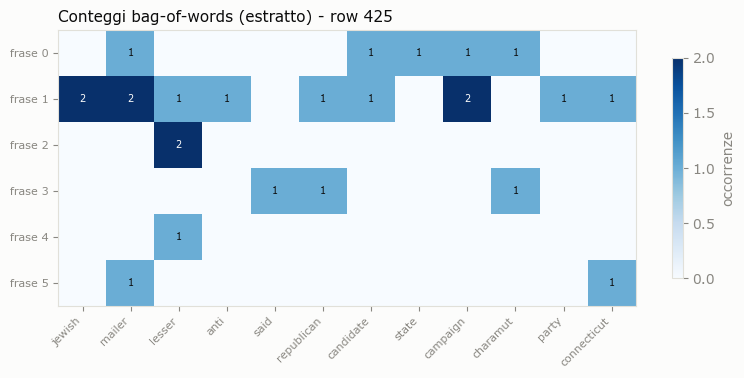

In [5]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer

conteggi = CountVectorizer(stop_words='english')
X = conteggi.fit_transform(frasi)
vocab = conteggi.get_feature_names_out()
densita = X.nnz / (X.shape[0] * X.shape[1])
print('PASSO 2 - Matrice dei conteggi (bag-of-words)')
print(f'{X.shape[0]} frasi x {len(vocab)} termini (sparsa, {densita:.1%} celle non nulle)')

# Termini piu' frequenti nel cluster + anteprima dei conteggi
freq = np.asarray(X.sum(axis=0)).ravel()
top_termini = np.argsort(-freq)[:12]
nomi_top = [vocab[j] for j in top_termini]
n_ant = min(6, X.shape[0])
anteprima = pd.DataFrame(X[:n_ant][:, top_termini].toarray(), columns=nomi_top,
                         index=[f'frase {i}' for i in range(n_ant)])
print()
print('Anteprima conteggi (prime frasi x 12 termini piu\' frequenti):')
display(anteprima)

fig, ax = plt.subplots(figsize=(8, 0.38 * n_ant + 1.6), facecolor=SURFACE)
im = ax.imshow(anteprima.values, cmap='Blues', aspect='auto')
ax.set_xticks(range(len(nomi_top)))
ax.set_xticklabels(nomi_top, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(n_ant))
ax.set_yticklabels(anteprima.index, fontsize=8)
for (yy, xx), v in np.ndenumerate(anteprima.values):
    if v:
        ax.text(xx, yy, int(v), ha='center', va='center', fontsize=7,
                color=INK if v < anteprima.values.max() * 0.6 else SURFACE)
fig.colorbar(im, ax=ax, shrink=0.8, label='occorrenze')
ax.set_title(f'Conteggi bag-of-words (estratto) - row {rid}', color=INK, loc='left', fontsize=11)
plt.tight_layout()
_salva(fig, f'conteggi_row{rid}.png')
plt.show()

### Passo 3 — I temi latenti: β (topic → parole) e θ (frase → topic)

Si adatta LDA sui conteggi (`k = min(N_TOPICS, n_frasi)` temi). Da qui escono le due matrici del
modello generativo:

- **β** — per ogni tema, le parole più caratteristiche: è ciò che rende un tema *interpretabile*
  (prima figura, un pannello per tema, colore e titolo `T0…Tk` coerenti con le figure successive).
- **θ** — per ogni frase, la sua appartenenza a ciascun tema (seconda figura, heatmap): le frasi
  "monotematiche" hanno una cella accesa, quelle generiche si spalmano su più temi. Le righe
  color acqua sono le frasi che il metodo selezionerà.

PASSO 3 - LDA con k=5 temi; matrice theta (71, 5) (frase x topic)
Parole-chiave per tema (β):
  T0: said, people, just, lesser, ad, worst, kind, aren
  T1: jewish, mailer, candidate, republican, state, anti, charamut, campaign
  T2: ad, anti, said, hateful, hartford, courant, black, did
  T3: lesser, mailer, said, anti, altered, jewish, look, greenspan
  T4: campaign, said, lesser, mailer, jewish, rep, statement, trying


  figura salvata: C:\Users\maccu\OneDrive\Desktop\Master_Project\results\figures\lda\parole_topic_row425.png


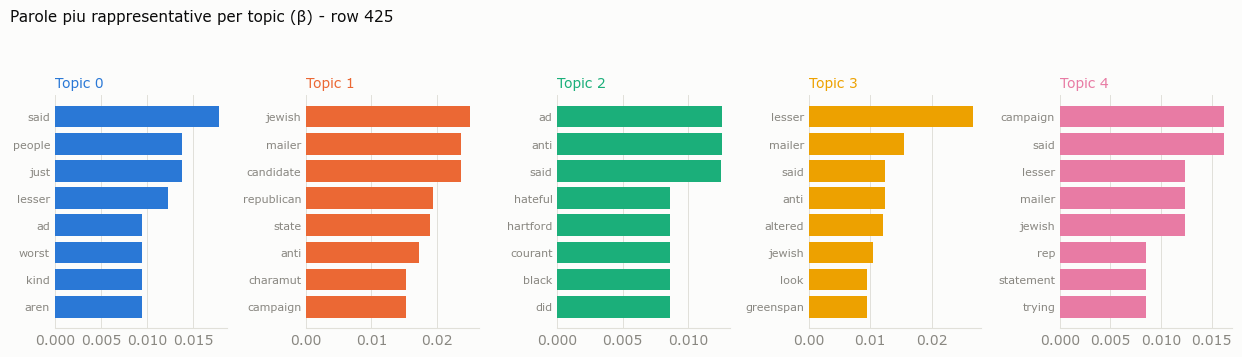

  figura salvata: C:\Users\maccu\OneDrive\Desktop\Master_Project\results\figures\lda\heatmap_theta_row425.png


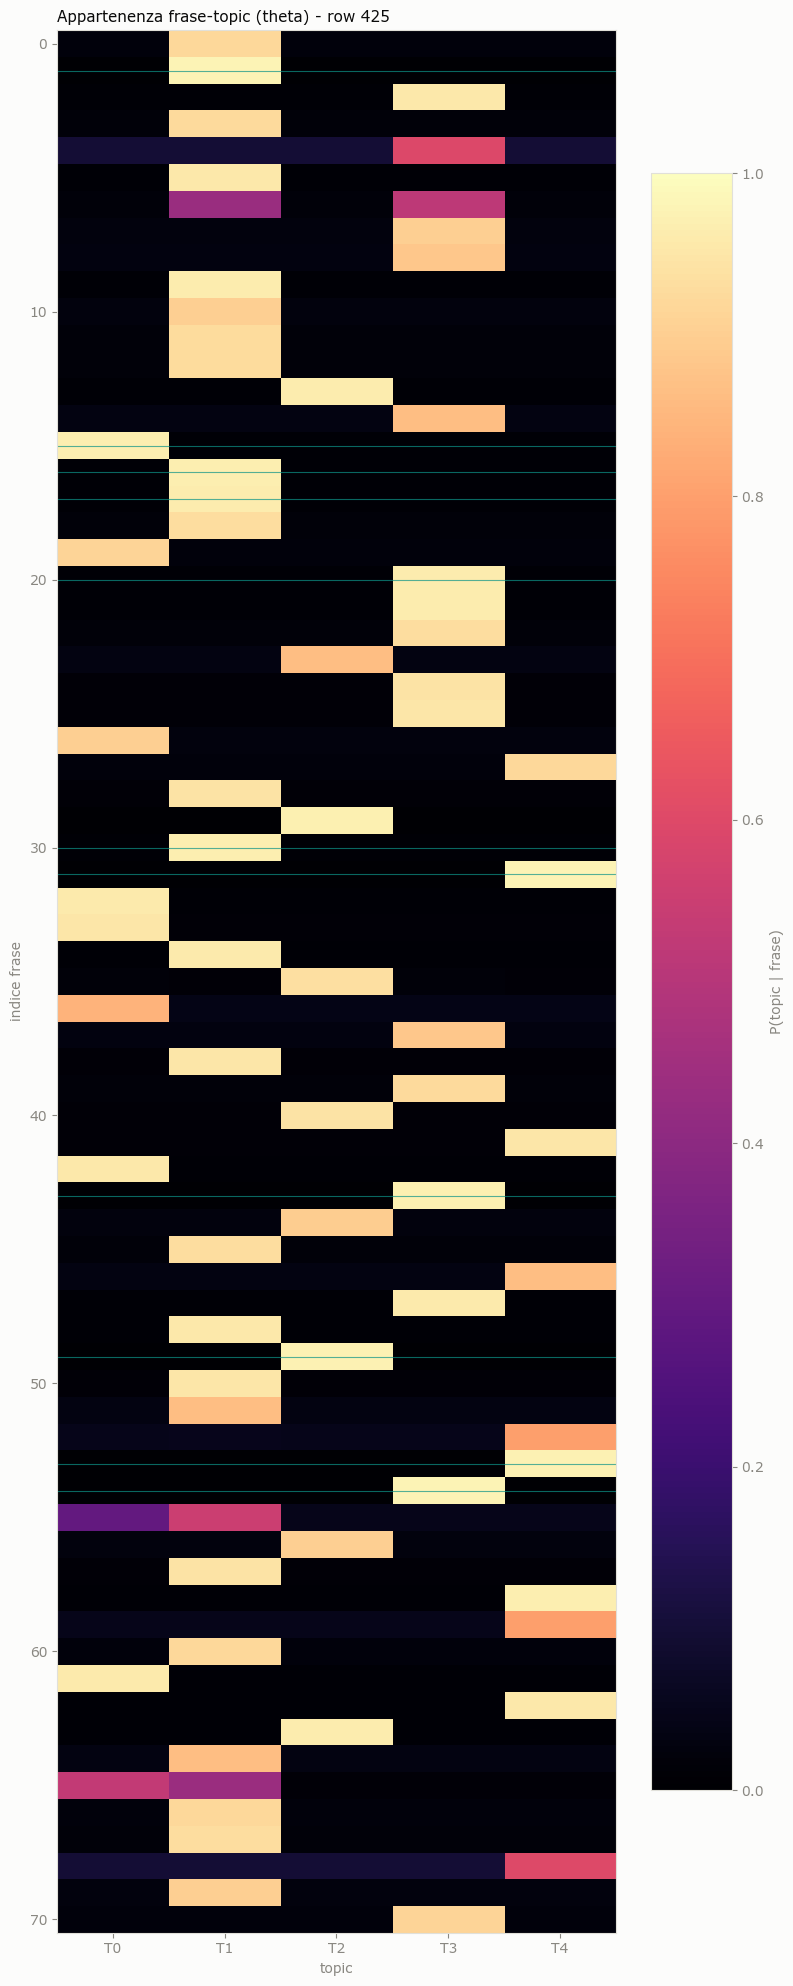

Linee color acqua = frasi selezionate dal metodo.


In [6]:
art = analizza_lda(frasi)
theta, peso, quote, scelti, k = (art['theta'], art['peso_topic'], art['quote'],
                                 art['scelti'], art['k'])
comp = art['componenti']
print(f'PASSO 3 - LDA con k={k} temi; matrice theta {theta.shape} (frase x topic)')
print('Parole-chiave per tema (β):')
for t in range(k):
    parole = [vocab[j] for j in np.argsort(-comp[t])[:N_PAROLE_TOP]]
    print(f"  T{t}: {', '.join(parole)}")

# --- Figura: parole piu' rappresentative per topic (β) ----------------------
fig, axes = plt.subplots(1, k, figsize=(2.4 * k + 0.5, 0.30 * N_PAROLE_TOP + 1.2),
                         facecolor=SURFACE)
axes = np.atleast_1d(axes)
for t, ax in enumerate(axes):
    ax.set_facecolor(SURFACE)
    idx = np.argsort(-comp[t])[:N_PAROLE_TOP][::-1]
    ax.barh(range(len(idx)), comp[t][idx] / comp[t].sum(), color=col_topic(t), zorder=2)
    ax.set_yticks(range(len(idx)))
    ax.set_yticklabels([vocab[j] for j in idx], fontsize=8)
    ax.set_title(f'Topic {t}', color=col_topic(t), loc='left', fontsize=10)
    ax.grid(axis='x', color=GRID, linewidth=0.7, zorder=0)
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.tick_params(length=0)
fig.suptitle(f'Parole piu rappresentative per topic (β) - row {rid}', color=INK, x=0.01,
             ha='left', fontsize=11)
fig.tight_layout(rect=[0, 0, 1, 0.92])
_salva(fig, f'parole_topic_row{rid}.png')
plt.show()

# --- Figura: heatmap theta (frase x topic) ----------------------------------
fig, ax = plt.subplots(figsize=(1.1 * k + 2.5, 0.26 * len(frasi) + 1.5), facecolor=SURFACE)
im = ax.imshow(theta, cmap='magma', vmin=0, vmax=1, aspect='auto')
for i in scelti:
    ax.axhline(i, color=ACCENTO, linewidth=0.8, alpha=0.7)
fig.colorbar(im, ax=ax, shrink=0.85, label='P(topic | frase)')
ax.set_xticks(range(k))
ax.set_xticklabels([f'T{t}' for t in range(k)])
ax.set_title(f'Appartenenza frase-topic (theta) - row {rid}', color=INK, loc='left', fontsize=11)
ax.set_xlabel('topic')
ax.set_ylabel('indice frase')
plt.tight_layout()
_salva(fig, f'heatmap_theta_row{rid}.png')
plt.show()
print('Linee color acqua = frasi selezionate dal metodo.')

### Passo 4 — Allocazione proporzionale e copertura tematica

Il budget di `N_SENTENCES` frasi viene ripartito tra i temi **in proporzione al loro peso** nel
cluster (`peso_topic = Σ_frasi θ`); dentro ogni tema si prendono le frasi con appartenenza più
alta. La prima figura mostra peso e quota per tema. La **mappa tematica** (seconda figura) dispone
le frasi in ordine di documento sull'asse x e il loro **tema dominante** sull'asse y: si vede a
colpo d'occhio come i temi si alternano nel testo e quali frasi (cerchiate) il metodo seleziona —
l'obiettivo è **toccare tutti i temi**, non concentrarsi sul più frequente. La stampa finale
confronta la copertura tematica dell'allocazione proporzionale con una baseline ingenua
("prime `N_SENTENCES` frasi per salienza"), che tende a concentrarsi su meno temi.

PASSO 4 - Allocazione: quote di frasi per tema = [1, 4, 1, 3, 2] (somma 11 = N_SENTENCES)
  figura salvata: C:\Users\maccu\OneDrive\Desktop\Master_Project\results\figures\lda\peso_topic_row425.png


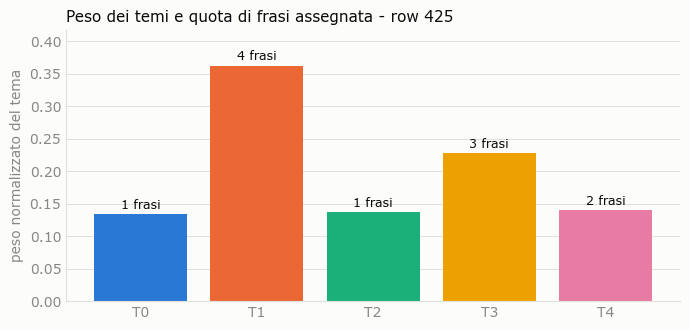

  figura salvata: C:\Users\maccu\OneDrive\Desktop\Master_Project\results\figures\lda\mappa_tematica_row425.png


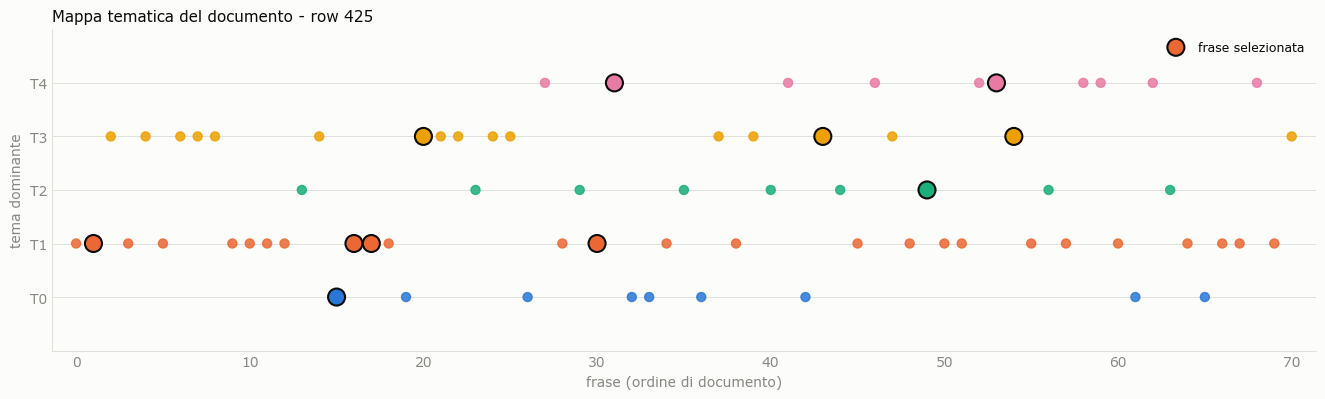


Copertura tematica della selezione:
  allocazione proporzionale        : temi [0, 1, 2, 3, 4] (5/5)
  baseline top-11 per salienza  : temi [0, 1, 2, 3, 4] (5/5)

Frasi selezionate (ordine di documento), con tema dominante:
  [ 1] (T1) The Jewish campaign treasurer for a Republican candidate in Connecticut is defending a campaign mailer that depicts their Democratic Party o
  [15] (T0) There aren’t ‘two sides’ to anti-Semitism, and there aren’t good people on ‘both sides’ of bigotry.” 
 
 This is the worst kind of antisem
  [16] (T1) — Gabe Rosenberg (@Gaber205) October 30, 2018
A mailer sent out by Republican state Senate candidate Ed Charamut in Connecticut depicts his 
  [17] (T1) (Ben Lovejoy) 
 
 A campaign mailer sent out by a Republican candidate for a state Senate seat in Connecticut is being widely denounced fo
  [20] (T3) The mailer drew wide outrage after its existence was reported on Tuesday, as concern about rising anti-Semitism runs high in the wake of the
  [30] (T1) “We

In [7]:
print(f'PASSO 4 - Allocazione: quote di frasi per tema = {list(map(int, quote))} '
      f'(somma {int(quote.sum())} = N_SENTENCES)')

# --- Figura: peso dei temi e quota di frasi assegnata -----------------------
peso_norm = peso / peso.sum()
fig, ax = plt.subplots(figsize=(1.0 * k + 2.0, 3.4), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
ax.bar(range(k), peso_norm, color=[col_topic(t) for t in range(k)], zorder=2)
for t in range(k):
    ax.annotate(f'{int(quote[t])} frasi', (t, peso_norm[t]), xytext=(0, 4),
                textcoords='offset points', ha='center', fontsize=9, color=INK)
ax.set_xticks(range(k))
ax.set_xticklabels([f'T{t}' for t in range(k)])
ax.set_title(f'Peso dei temi e quota di frasi assegnata - row {rid}', color=INK, loc='left',
             fontsize=11)
ax.set_ylabel('peso normalizzato del tema')
ax.grid(axis='y', color=GRID, linewidth=0.7, zorder=0)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(length=0)
ax.margins(y=0.15)
plt.tight_layout()
_salva(fig, f'peso_topic_row{rid}.png')
plt.show()

# --- Figura: mappa tematica del documento -----------------------------------
# x = frase in ordine di documento; y = tema dominante (la POSIZIONE e' l'identita' del tema,
# il colore la ribadisce). Le frasi cerchiate (bordo nero) sono quelle selezionate dal metodo.
dominante = theta.argmax(axis=1)
sel = np.zeros(len(frasi), dtype=bool)
sel[scelti] = True
fig, ax = plt.subplots(figsize=(min(0.16 * len(frasi) + 2, 15), 0.5 * k + 1.6), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
ax.scatter(np.where(~sel)[0], dominante[~sel], s=42,
           c=[col_topic(t) for t in dominante[~sel]], alpha=0.85, zorder=2)
ax.scatter(np.where(sel)[0], dominante[sel], s=150,
           c=[col_topic(t) for t in dominante[sel]], edgecolors=INK, linewidths=1.5,
           zorder=3, label='frase selezionata')
ax.set_yticks(range(k))
ax.set_yticklabels([f'T{t}' for t in range(k)])
ax.set_xlabel('frase (ordine di documento)')
ax.set_ylabel('tema dominante')
ax.set_title(f'Mappa tematica del documento - row {rid}', color=INK, loc='left', fontsize=11)
ax.grid(axis='y', color=GRID, linewidth=0.7, zorder=0)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(length=0)
ax.legend(frameon=False, fontsize=9, loc='upper right')
ax.margins(x=0.02, y=0.25)
plt.tight_layout()
_salva(fig, f'mappa_tematica_row{rid}.png')
plt.show()

# --- Copertura tematica: proporzionale vs baseline "top-N per salienza" ------
propor = sorted(set(int(dominante[i]) for i in scelti))
salienza = theta.max(axis=1)
naive = sorted(set(int(dominante[i]) for i in np.argsort(-salienza)[:N_SENTENCES]))
print()
print('Copertura tematica della selezione:')
print(f'  allocazione proporzionale        : temi {propor} ({len(propor)}/{k})')
print(f'  baseline top-{N_SENTENCES} per salienza  : temi {naive} ({len(naive)}/{k})')
print()
print('Frasi selezionate (ordine di documento), con tema dominante:')
for i in sorted(scelti):
    print(f'  [{i:>2}] (T{int(dominante[i])}) {frasi[i][:140]}')

## Valutazione (indipendente dalla generazione)

Legge **solo** i file salvati; rieseguibile senza rigenerare i riassunti. Metriche ROUGE-1/2/L
(F1, precisione, recall), BLEU e METEOR con la normalizzazione identica a tutti i metodi del
benchmark. Output: `results/metrics/{metodo}_{scope}_per_example.csv` e `…_aggregate.json`.

In [8]:
import json

out_path    = P['summaries_dir'] / f'{METODO}_{SCOPE}.tsv'
riassunti   = su.carica_riassunti(out_path)
riferimenti = esempi_scope()
config = {'n_topics': N_TOPICS, 'n_sentences': N_SENTENCES,
          'segmentazione': 'psr.summarization',
          'vettorizzazione': 'sklearn CountVectorizer (stop_words=english)',
          'modello': 'sklearn LatentDirichletAllocation',
          'selezione': 'allocazione proporzionale ai pesi dei topic',
          'libreria_valutazione': 'pyAutoSummarizer 1.2.0'}
righe, aggregato = su.valuta_e_salva(riferimenti, riassunti, METODO, SCOPE,
                                     P['metrics_dir'], config)

print()
print('Medie complessive:')
print(json.dumps(aggregato['overall'], indent=2))

Metriche per-esempio : C:\Users\maccu\OneDrive\Desktop\Master_Project\results\metrics\lda_test_per_example.csv (5588 righe)
Metriche aggregate   : C:\Users\maccu\OneDrive\Desktop\Master_Project\results\metrics\lda_test_aggregate.json

Medie complessive:
{
  "rouge1_f1": 0.3509846233862047,
  "rouge1_p": 0.2798595432870667,
  "rouge1_r": 0.4985803958745332,
  "rouge2_f1": 0.12977363029462377,
  "rouge2_p": 0.10054190362027153,
  "rouge2_r": 0.19773255842034027,
  "rougeL_f1": 0.17130052382986646,
  "rougeL_p": 0.1292862591041241,
  "rougeL_r": 0.2770117992950252,
  "bleu": 0.08064305692905456,
  "meteor": 0.5111659057612757,
  "parole_generate": 477.2406943450251
}


## Ispezione qualitativa

Qualche coppia generato/riferimento, utile per vedere a occhio se la selezione per topic copre
temi diversi e se le frasi scelte sono effettivamente rappresentative del cluster.

In [9]:
# --- Ispezione qualitativa --------------------------------------------------
# Sugli ambiti grandi (test/full) il default e' 3 esempi: con None il notebook
# eseguito conterrebbe migliaia di documenti interi.
N_ISPEZIONE      = None if SCOPE == 'sample' else 3   # un intero oppure None = tutti
MOSTRA_DOCUMENTO = True   # False per nascondere gli articoli sorgente (output piu' corto)

riferimenti = esempi_scope()
riassunti = su.carica_riassunti(P['summaries_dir'] / f'{METODO}_{SCOPE}.tsv')

mostrati = 0
for rif in riferimenti:
    rid = rif['row_id']
    if rid not in riassunti:
        continue
    if N_ISPEZIONE is not None and mostrati >= N_ISPEZIONE:
        break
    print('=' * 100)
    print(f"row_id={rid} | split={rif['split']}")
    if MOSTRA_DOCUMENTO:
        articoli = [a.strip() for a in rif['document'].split(su.SEPARATORE_ARTICOLI) if a.strip()]
        print()
        print(f'----- DOCUMENTO ({len(articoli)} articoli) -----')
        for i, art in enumerate(articoli, 1):
            print(f'[articolo {i}]')
            print(art)
            print()
    print('----- RIFERIMENTO -----')
    print(su.pulisci_riferimento(rif['summary']))
    print()
    print(f'----- GENERATO [{METODO}] -----')
    print(riassunti[rid])
    print()
    mostrati += 1
print()
print(f'({mostrati} esempi mostrati)')

row_id=50491 | split=test

----- DOCUMENTO (2 articoli) -----
[articolo 1]
GOP Eyes Gains As Voters In 11 States Pick Governors 
 
 Enlarge this image toggle caption Jim Cole/AP Jim Cole/AP 
 
 Voters in 11 states will pick their governors tonight, and Republicans appear on track to increase their numbers by at least one, with the potential to extend their hold to more than two-thirds of the nation's top state offices. 
 
 Eight of the gubernatorial seats up for grabs are now held by Democrats; three are in Republican hands. Republicans currently hold 29 governorships, Democrats have 20, and Rhode Island's Gov. Lincoln Chafee is an Independent. 
 
 Polls and race analysts suggest that only three of tonight's contests are considered competitive, all in states where incumbent Democratic governors aren't running again: Montana, New Hampshire and Washington. 
 
 While those state races remain too close to call, Republicans are expected to wrest the North Carolina governorship from Democrat